In [158]:
from pyfiles.preamble import *
enable_autoreload()

INPUT_DIR = Path("..") / "ZipEnergyPLAN163" / "energyPlan Data" / "Data"
OUT_DIR = Path("0_EP_runs")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [159]:
from pyfiles.create_scenario import create_scenarios
create_scenarios()

Written: 2024_base_v3.txt
Written: 2024_shock_v3.txt


# Run EnergyPLAN

Executes both scenarios via `ep_run_v2.run_many`, which calls the EnergyPLAN binary and saves outputs directly to parquet. Downstream figure notebooks are then run automatically.

*Specify input files and output names, then run both scenarios.*

In [160]:
inp_file = ['2024_base_v3.txt', '2024_shock_v3.txt']
out_name = ['ETT_base_v3', 'ETT_shock_v3']

all_paths = ep_run_v2.run_many(inp_file, out_name, input_dir=INPUT_DIR)

for name, run_paths in zip(out_name, all_paths):
    keys = ', '.join(f'{k}: {p.name}' for k, p in run_paths.items())
    print(f'{name}: {keys}')

ETT_base_v3: scalars: ETT_base_v3_scalars.parquet, annual: ETT_base_v3_annual.parquet, monthly: ETT_base_v3_monthly.parquet, hourly: ETT_base_v3_hourly.parquet, investments: ETT_base_v3_investments.parquet
ETT_shock_v3: scalars: ETT_shock_v3_scalars.parquet, annual: ETT_shock_v3_annual.parquet, monthly: ETT_shock_v3_monthly.parquet, hourly: ETT_shock_v3_hourly.parquet, investments: ETT_shock_v3_investments.parquet


*Execute downstream figure notebooks.*

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


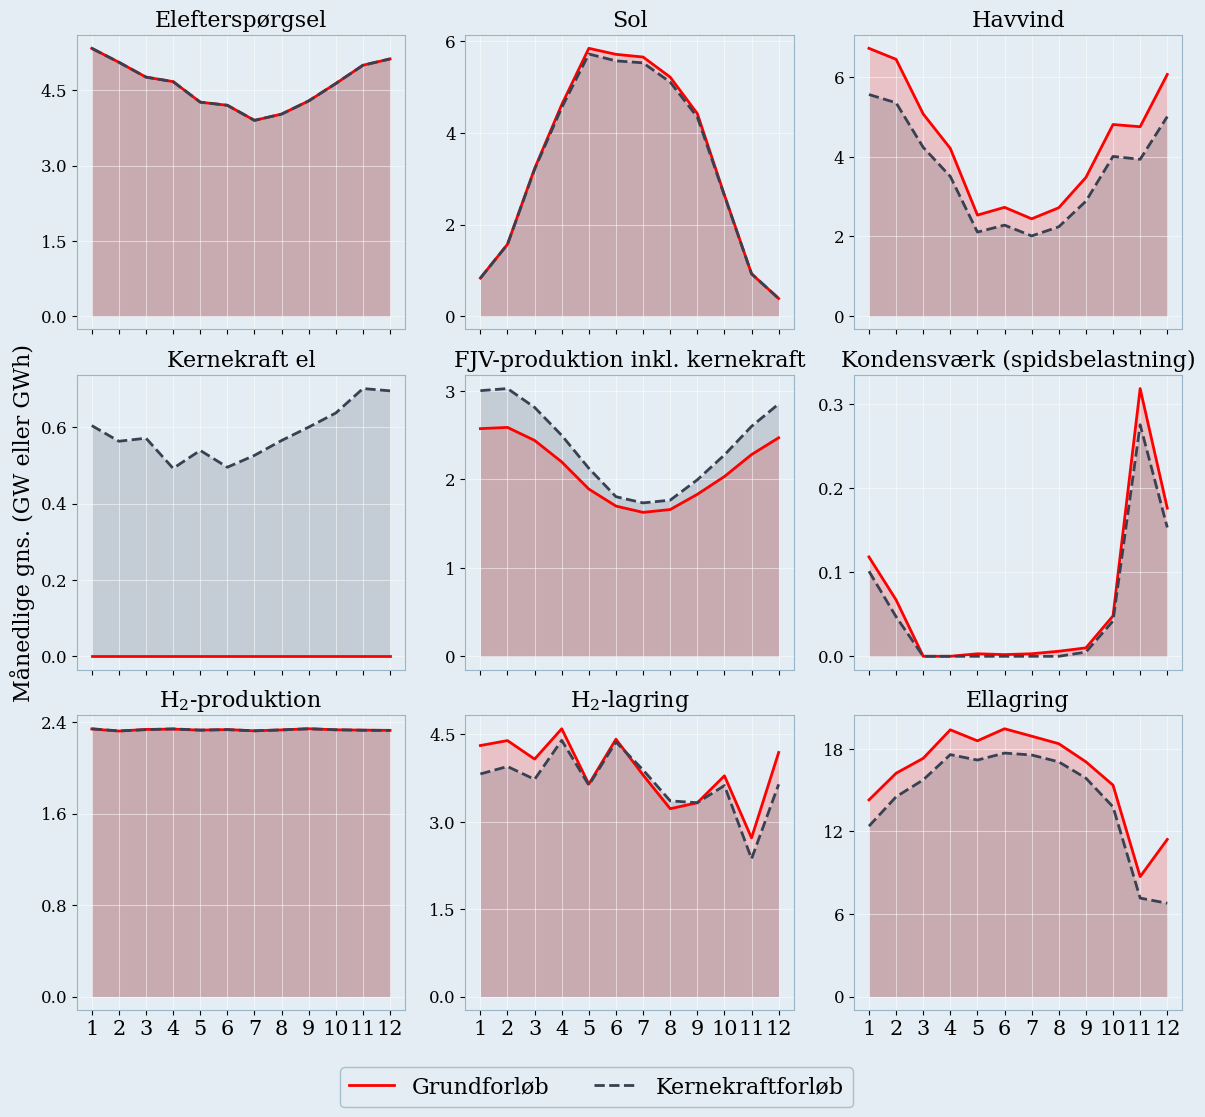

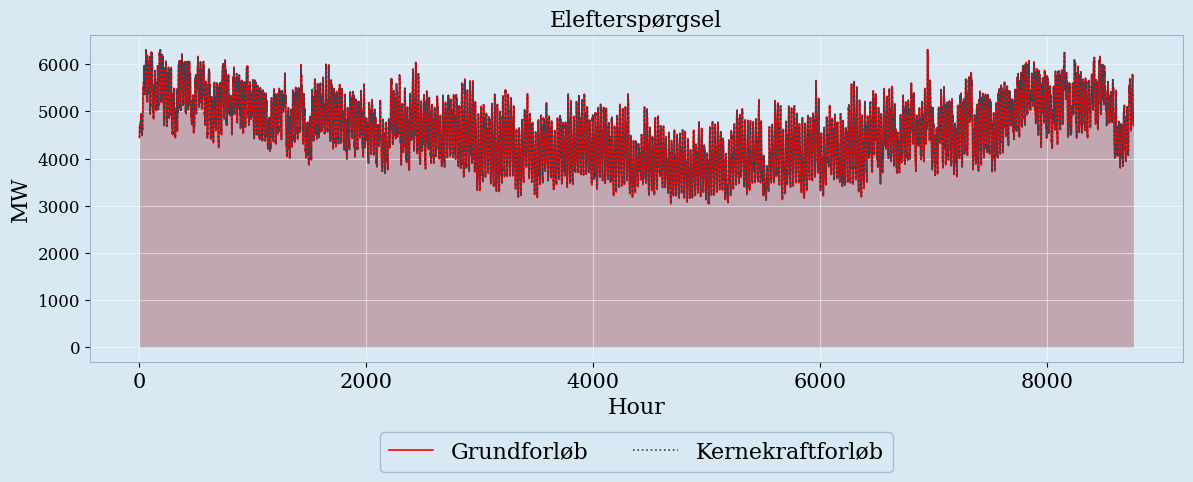

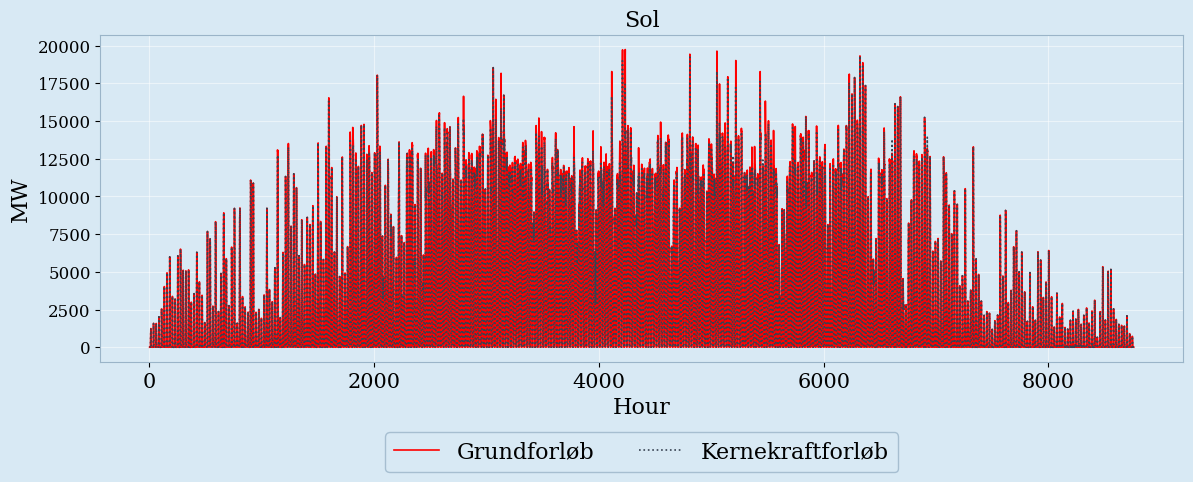

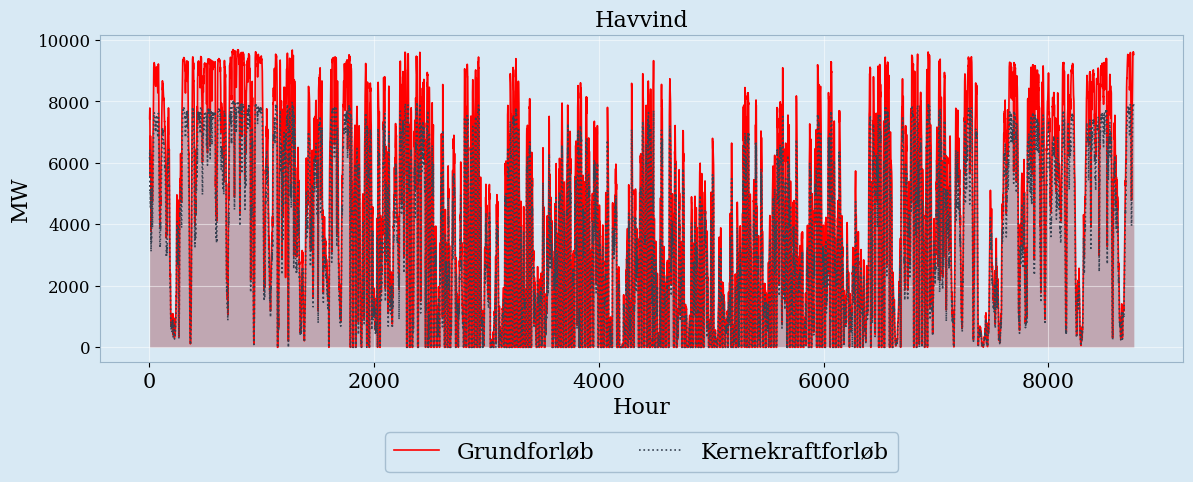

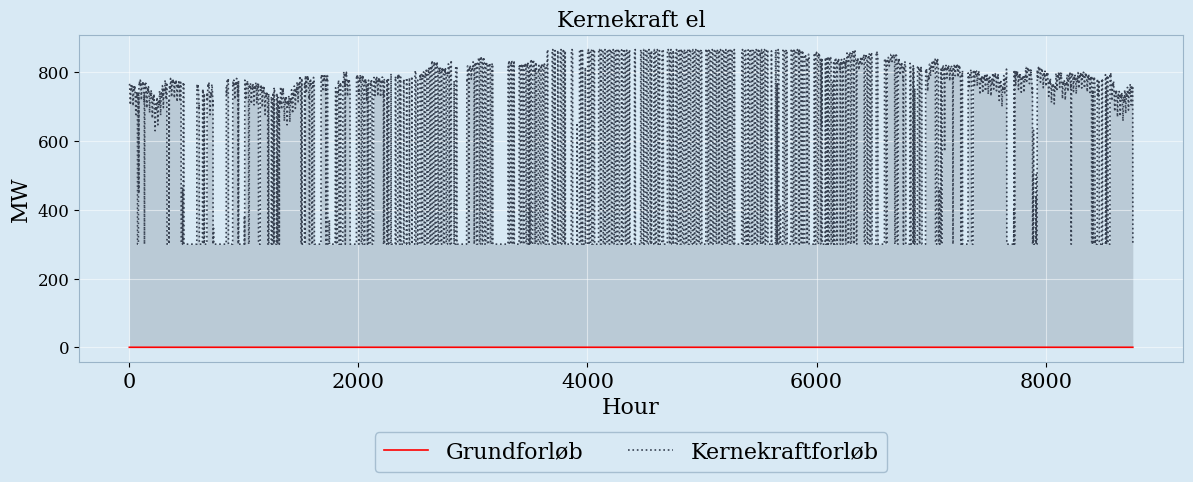

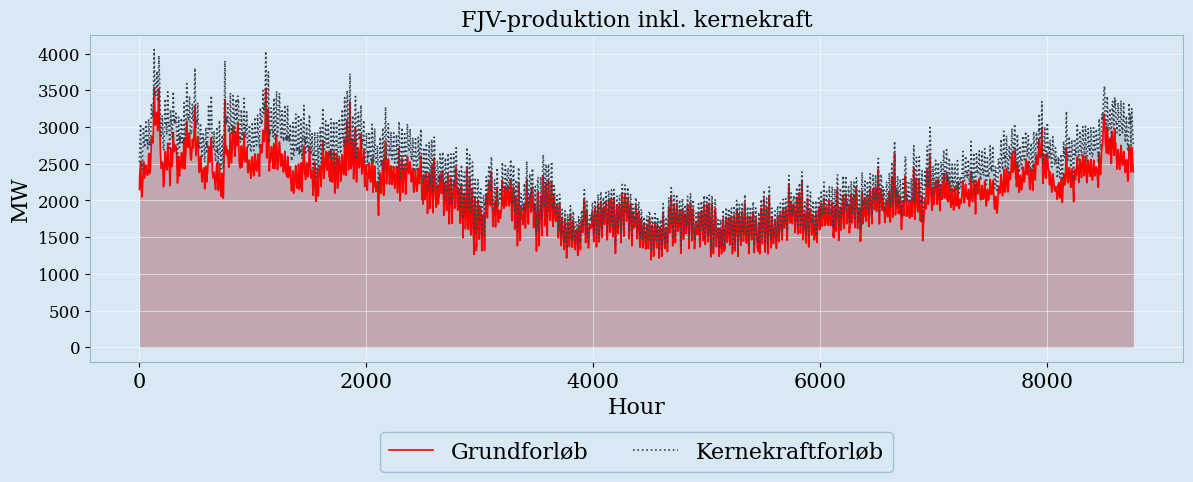

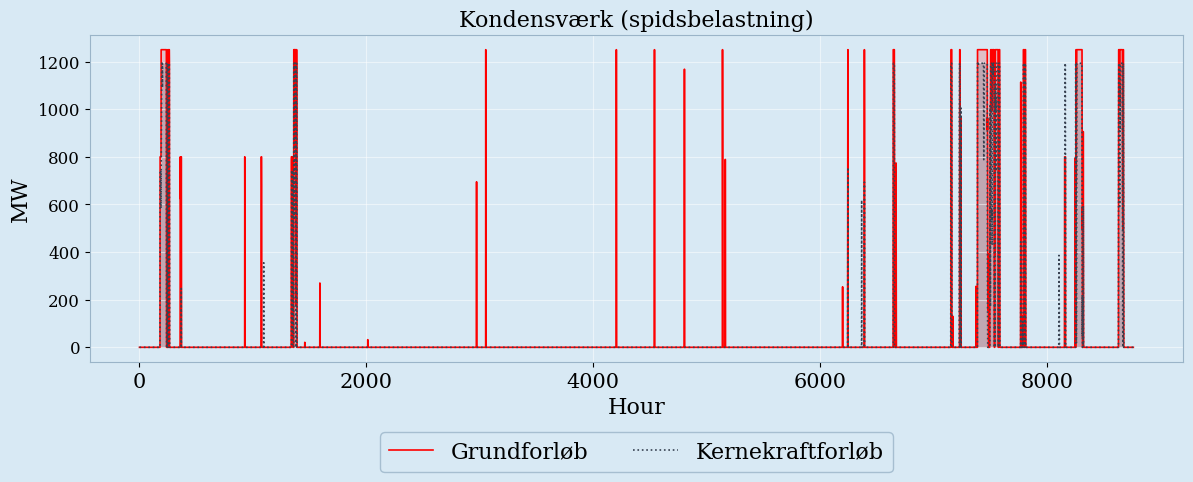

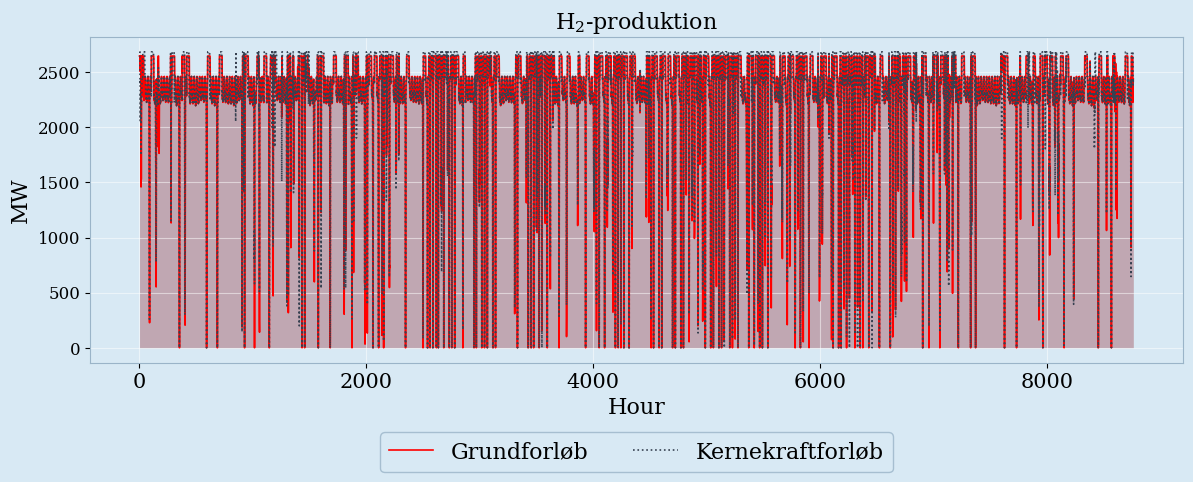

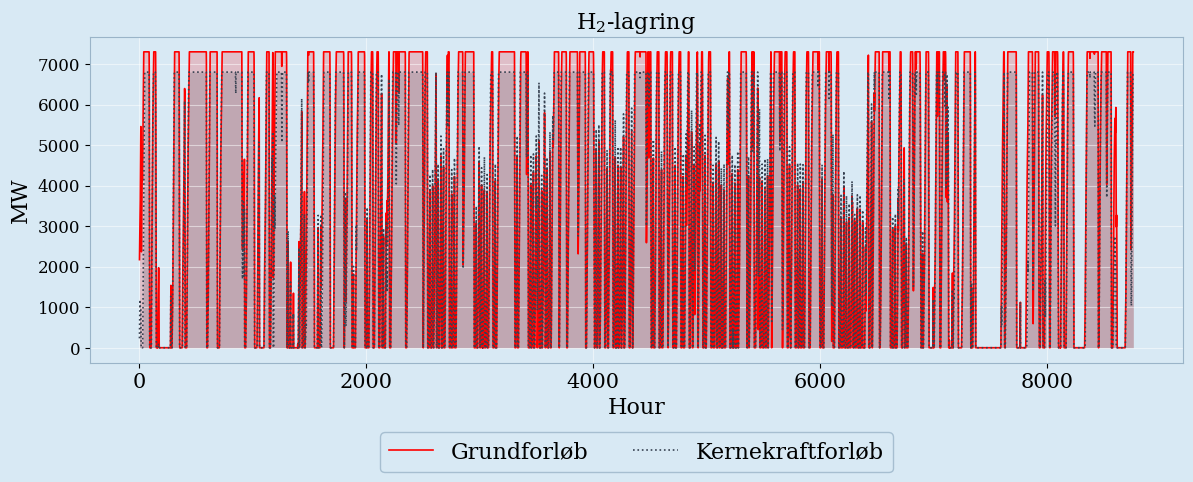

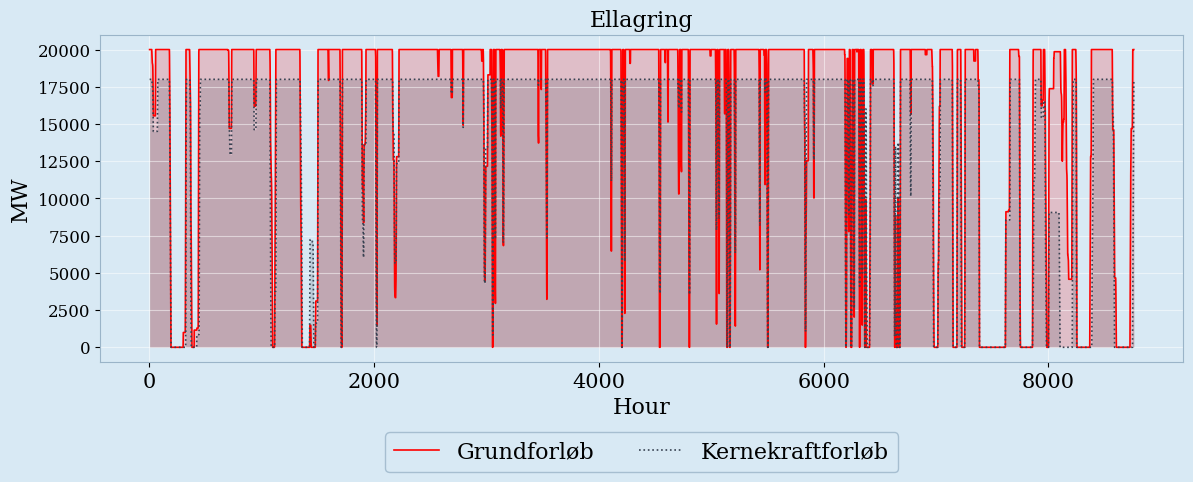

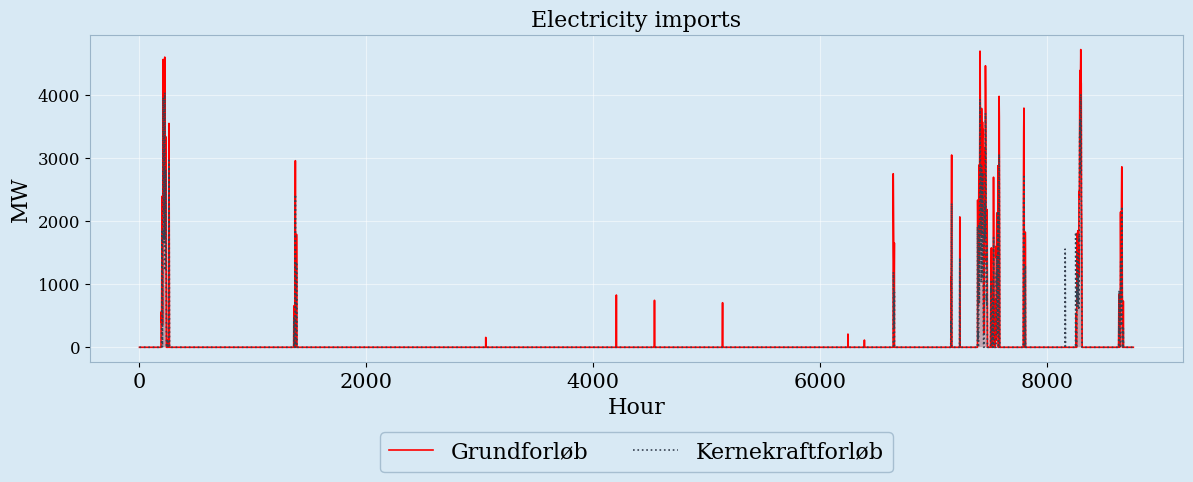

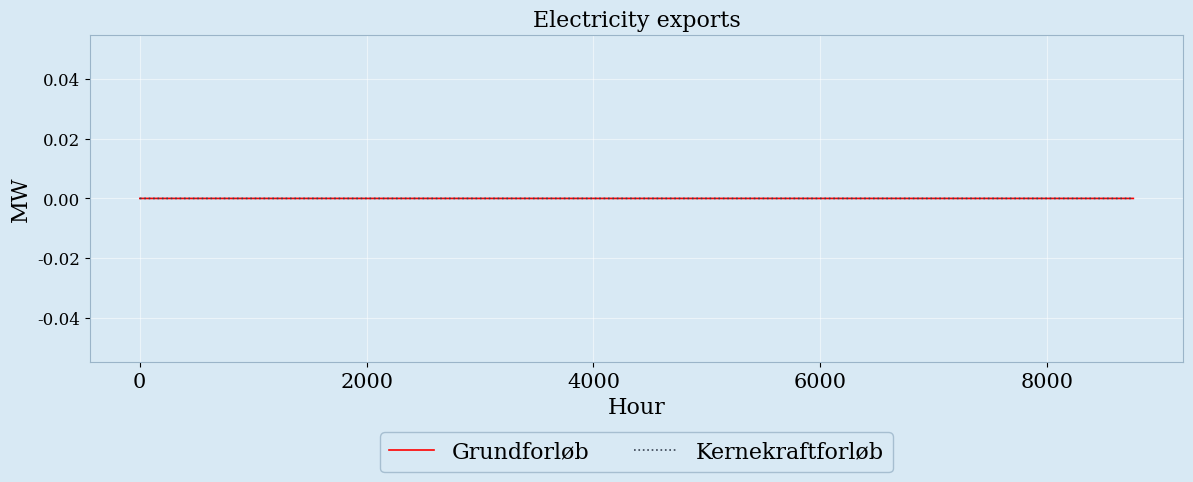

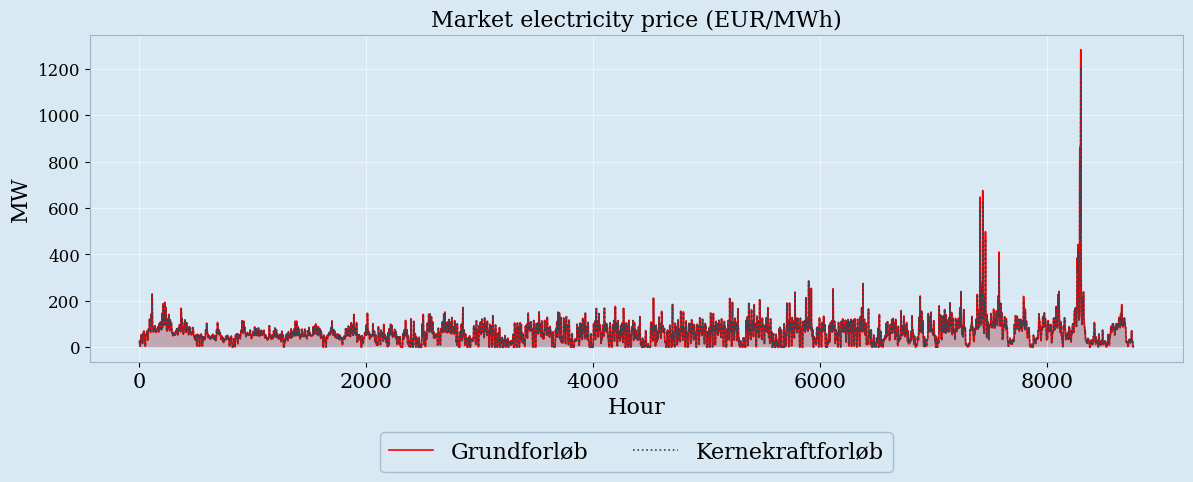

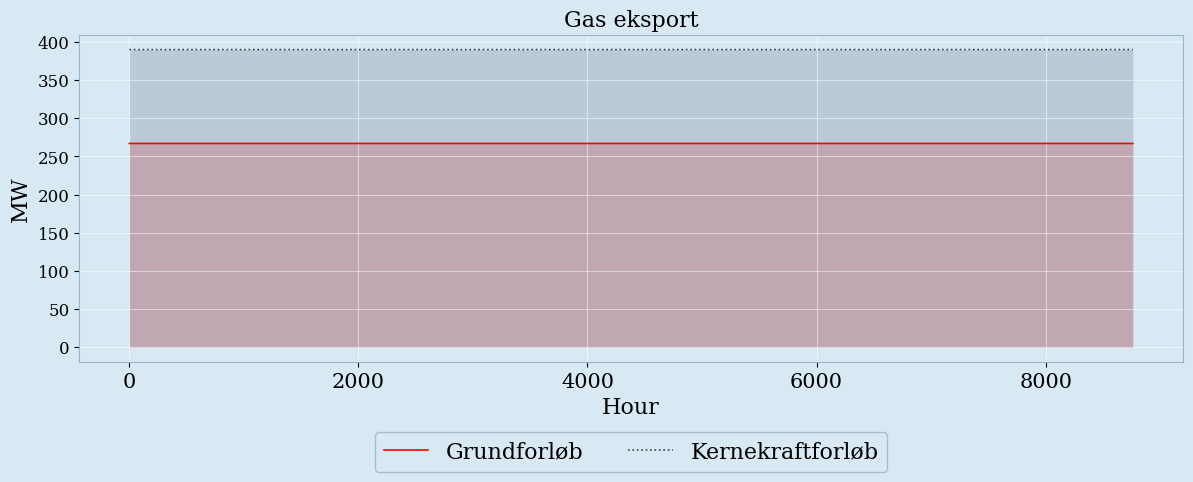

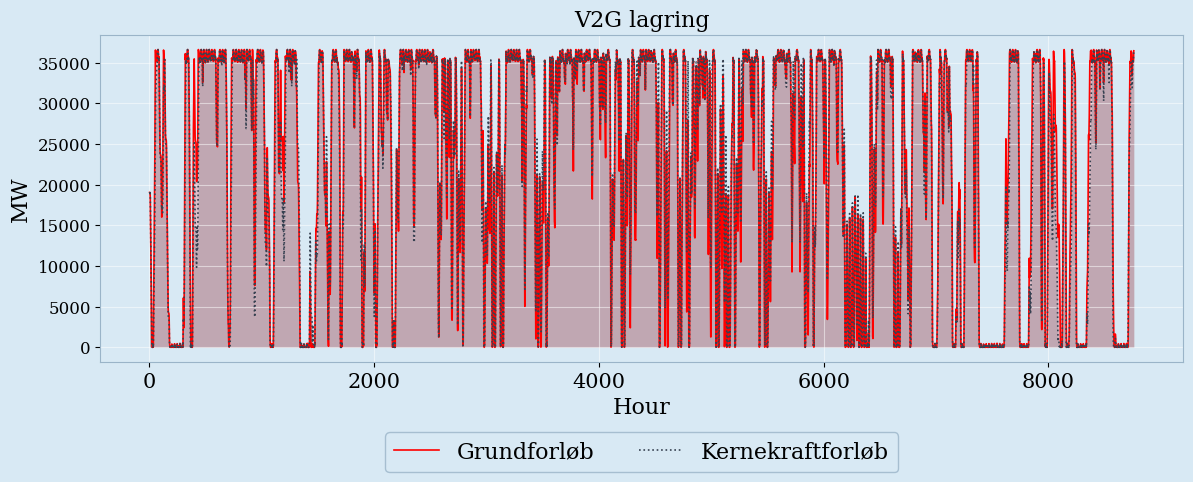

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

INVESTMENT and O&M:
Nuclear                    420.0 MEUR
Wind offshore             -296.0 MEUR
El1 storage cap            -39.0 MEUR
Indust. CHP Heat            10.0 MEUR
Electrolyser                 4.0 MEUR
Large Power Plants          -3.0 MEUR
Hydrogen Storage            -1.0 MEUR
Summing to: 95.00 MEUR

FUEL and MC:
Marginal operation costs..........................      74.0 MEUR
Fuel ex. Ngas exchange............................      47.0 MEUR
Electricity exchange..............................     -45.0 MEUR
Ngas Exchange costs...............................     -31.0 MEUR
CO2 emission costs................................       0.0 MEUR
Summing to: 45.00 MEUR
Fuel ex. Ngas exchange: 47 MEUR

Add system costs:
  VE prod:  base=84.12 TWh  shock=79.31 TWh  diff=-4.81 TWh
  KK prod:  5.12 TWh (shock only)
Delta system costs: -86.74 MEUR
  EP import diff (shock-base): -45.00 MEUR  (cross-check v

,KK inv.,MC,Brændsel,Havvind inv.,Fleks. & Stab.,Systemomk.,Bottom line
Value,420.0,74.0,47.0,-296.0,-115.0,-86.74,43.26


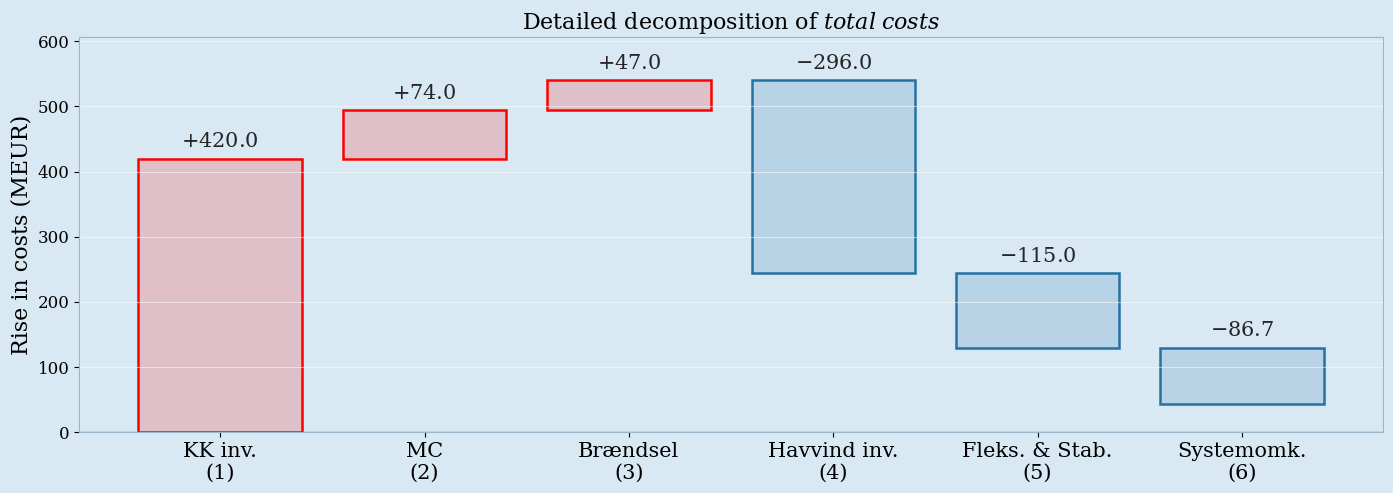


Waterfall with relative numbers: ================================
Table: detailed decomposition (%)


,KK inv.,MC,Brændsel,Havvind inv.,Fleks. & Stab.,Systemomk.,Bottom line
Value,1.65,0.29,0.18,-1.16,-0.45,-0.34,0.17


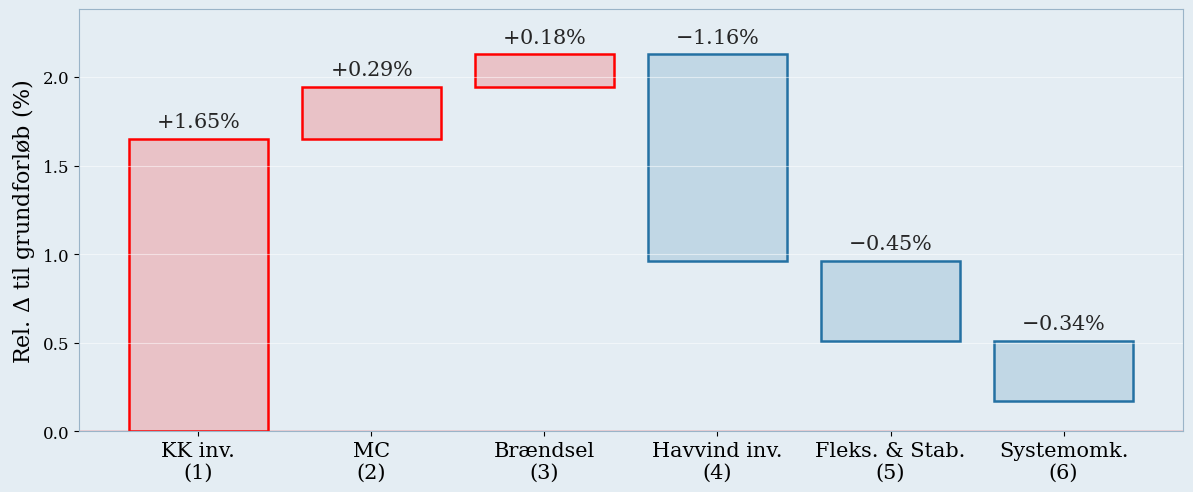

In [161]:
%run 4_time_series_output.ipynb
%run 5_cost_decomposition.ipynb